In [22]:
import pandas as pd
import numpy as np
import glob, os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 150        # screen quality
plt.rcParams['savefig.dpi'] = 300       # save quality
plt.rcParams['figure.figsize'] = (12, 5)

# ggplot2-like theme
sns.set_theme(
    style='whitegrid',
    font_scale=1.1,
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.family': 'sans-serif'
    }
)

In [3]:
'''
Please remember to comment out the code after you have a merged file, otherwise, it will keep merging the files and create a new merged file, 
which is not what we want. Also, remember to change the path to your own path, and make sure you have the same file structure as mine, 
otherwise, you may need to change the code a bit. It depends on how you organize your files, I still suggest you to follow the same file structure as mine, 
which is more organised and easier to manage.
'''

path = r'd:\USYD\DATA3888\group_asm\Optiver\individual_book_train'
files = glob.glob(os.path.join(path, "*.csv"))
print(files) 


[]


In [ ]:
''' 
These lines of code should be commented out after any of you guys already have a merged file. 
Basically, 126 csv files has been aggregated as week 3's material instruction indicated, the new merged file will contain stock information, WAP, BAS, and
log return.
'''

path = r'd:\USYD\DATA3888\group_asm\Optiver\individual_book_train'

conn = duckdb.connect()

result = conn.execute(f"""
    SELECT
        stock_id,
        time_id,
        CEIL(seconds_in_bucket / 30.0) AS time_bucket,
        AVG((bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
            (bid_size1 + ask_size1)) AS WAP_mean,
        AVG(ask_price1 / bid_price1 - 1) AS BidAskSpread_mean,
        SQRT(SUM(POWER(
            LN((bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
               (bid_size1 + ask_size1)), 2)
        )) AS volatility
    FROM read_csv_auto('{path}/*.csv')
    GROUP BY stock_id, time_id, time_bucket
    ORDER BY stock_id, time_id, time_bucket
""").df()  # returns a pandas dataframe

result.to_csv(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv', index=False)
print(result.shape)

(8998663, 6)


In [3]:
size_mb = os.path.getsize(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv') / (1024**2)
print(f"File size: {size_mb:.2f} MB")

#These code help you check if the current file is overloading your memory. In general, It should be fine for now.
df = pd.read_csv(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv')
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Shape: {df.shape}")
print(f"RAM usage: {mem_mb:.2f} MB")
print(df.head())

File size: 656.03 MB
Shape: (8998663, 6)
RAM usage: 411.93 MB
   stock_id  time_id  time_bucket  WAP_mean  BidAskSpread_mean  volatility
0         0        5          0.0  1.001434           0.000878    0.001433
1         0        5          1.0  1.001601           0.000957    0.006366
2         0        5          2.0  1.002978           0.000748    0.009511
3         0        5          3.0  1.003786           0.000876    0.011409
4         0        5          4.0  1.004046           0.000873    0.016157


In [23]:
df.isnull().sum()

stock_id             0
time_id              0
time_bucket          0
WAP_mean             0
BidAskSpread_mean    0
volatility           0
dtype: int64

In [25]:
print("\n=== Infinite values ===")
print(np.isinf(df[['WAP_mean', 'BidAskSpread_mean', 'volatility']]).sum())



=== Infinite values ===
WAP_mean             0
BidAskSpread_mean    0
volatility           0
dtype: int64


In [33]:
sns.set_theme(style='whitegrid')  # ggplot-like theme

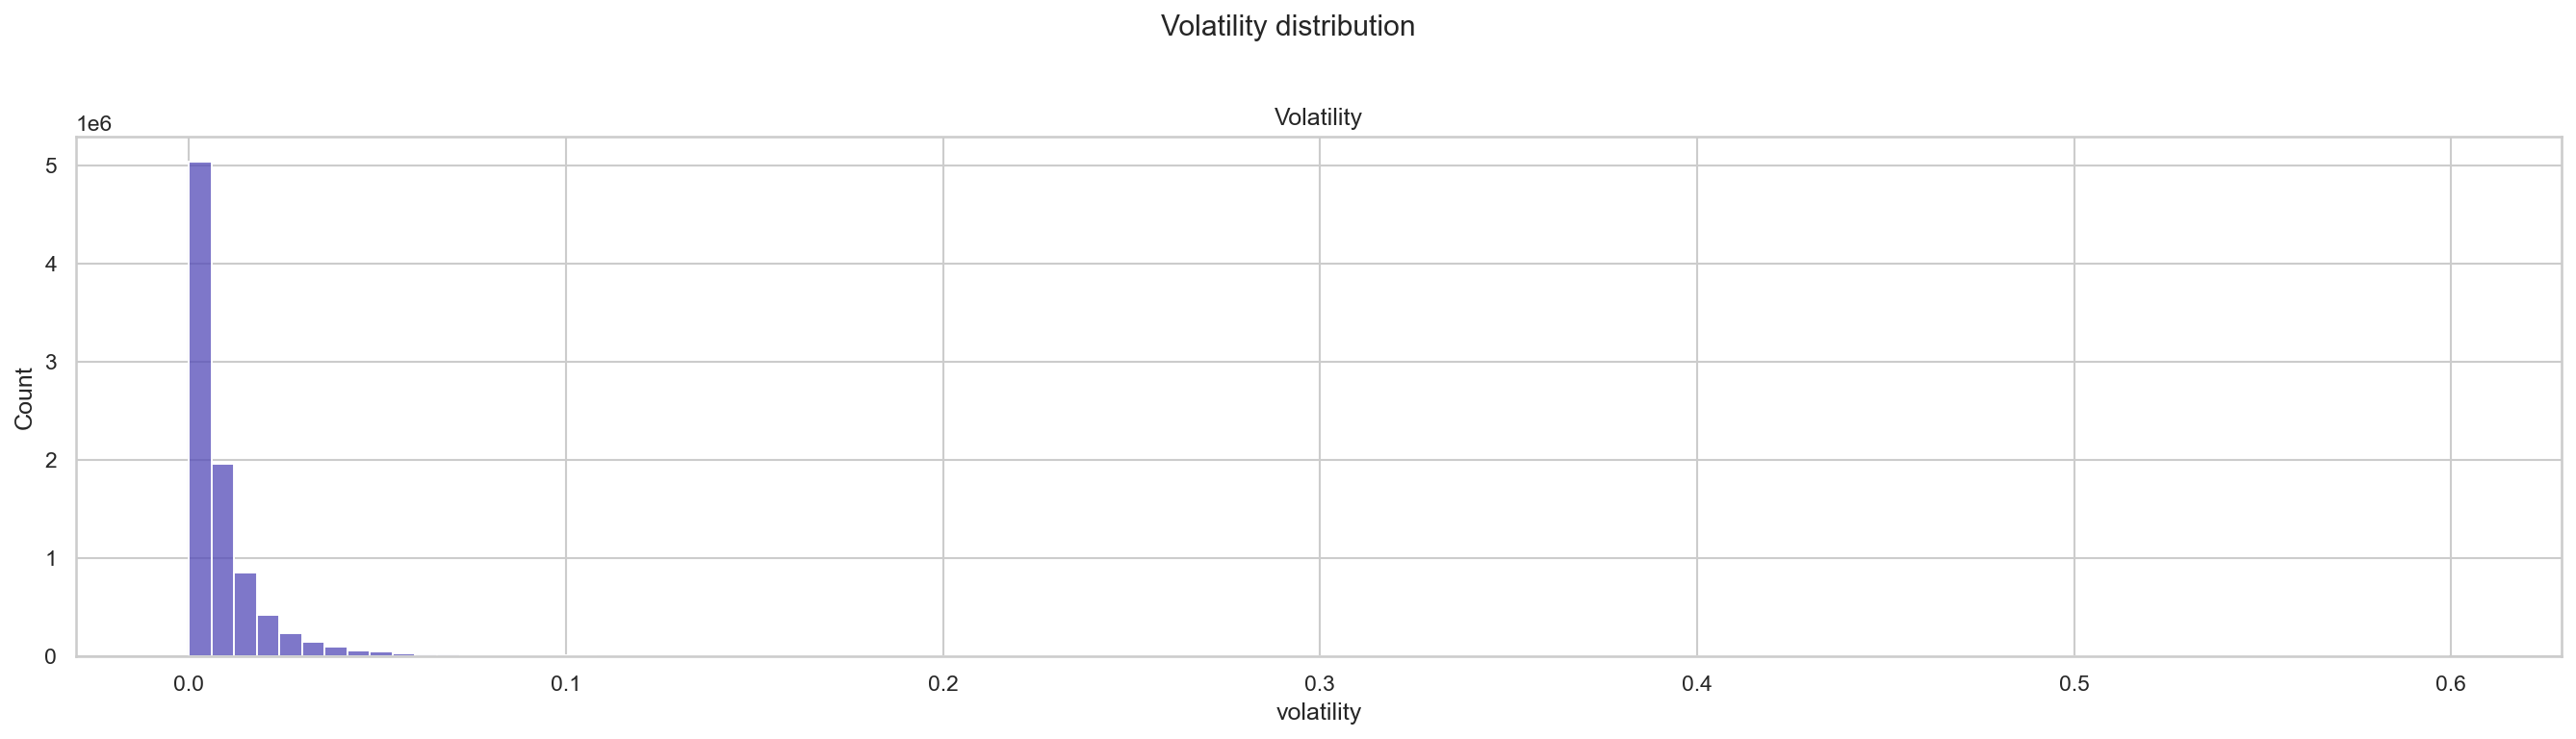

In [43]:
fig, axes = plt.subplots(1, 1, figsize=(18, 5))

sns.histplot(df['volatility'], bins=100, kde=False, color='#534AB7', ax=axes)


axes.set_title('Volatility')
plt.suptitle('Volatility distribution', y=1.02)
plt.tight_layout()
plt.show()



In [6]:
print(df['volatility'].quantile([0.9, 0.95, 0.99, 0.999, 1.0]))

# How many extreme outliers?
cap = df['volatility'].quantile(0.999)
print(f"Rows above 99.9th percentile: {(df['volatility'] > cap).sum()}")

0.900    0.020970
0.950    0.031084
0.990    0.065113
0.999    0.141370
1.000    0.599342
Name: volatility, dtype: float64
Rows above 99.9th percentile: 8999


In [9]:
cap_999 = df['volatility'].quantile(0.999)
extreme = df[df['volatility'] > cap_999]
print(f"Number of extreme rows: {len(extreme)}")
print(f"Which stocks: {extreme['stock_id'].value_counts()}")
print(f"Which time_ids: {extreme['time_id'].value_counts().head(10)}")

# Look at the worst offenders
print(df.nlargest(20, 'volatility')[['stock_id', 'time_id', 'time_bucket', 'volatility']])

Number of extreme rows: 8999
Which stocks: stock_id
80     1129
6       680
81      558
89      225
8       220
       ... 
113       7
110       6
64        5
69        5
53        1
Name: count, Length: 108, dtype: int64
Which time_ids: time_id
3138     461
19725    415
15155    324
19639    308
24349    266
30128    236
13735    219
24143    179
7564     157
11686    110
Name: count, dtype: int64
         stock_id  time_id  time_bucket  volatility
6637872        94    19639          4.0    0.599342
6637873        94    19639          5.0    0.592636
6637874        94    19639          6.0    0.591601
6351576        89     1946         19.0    0.588805
6351575        89     1946         18.0    0.576378
6351577        89     1946         20.0    0.568250
5692075        80    27278         19.0    0.558336
3745185        51    19725         16.0    0.547847
6351573        89     1946         16.0    0.545592
6172886        86    26786         20.0    0.543885
6351572        89     194

Stock 80 has nearly double the extreme volatility of stock 6 in second place. That's worth investigating. At the same time, let's have a look at time_id = 3138 to see what happened at that time as it recorded the most volatility of the market.

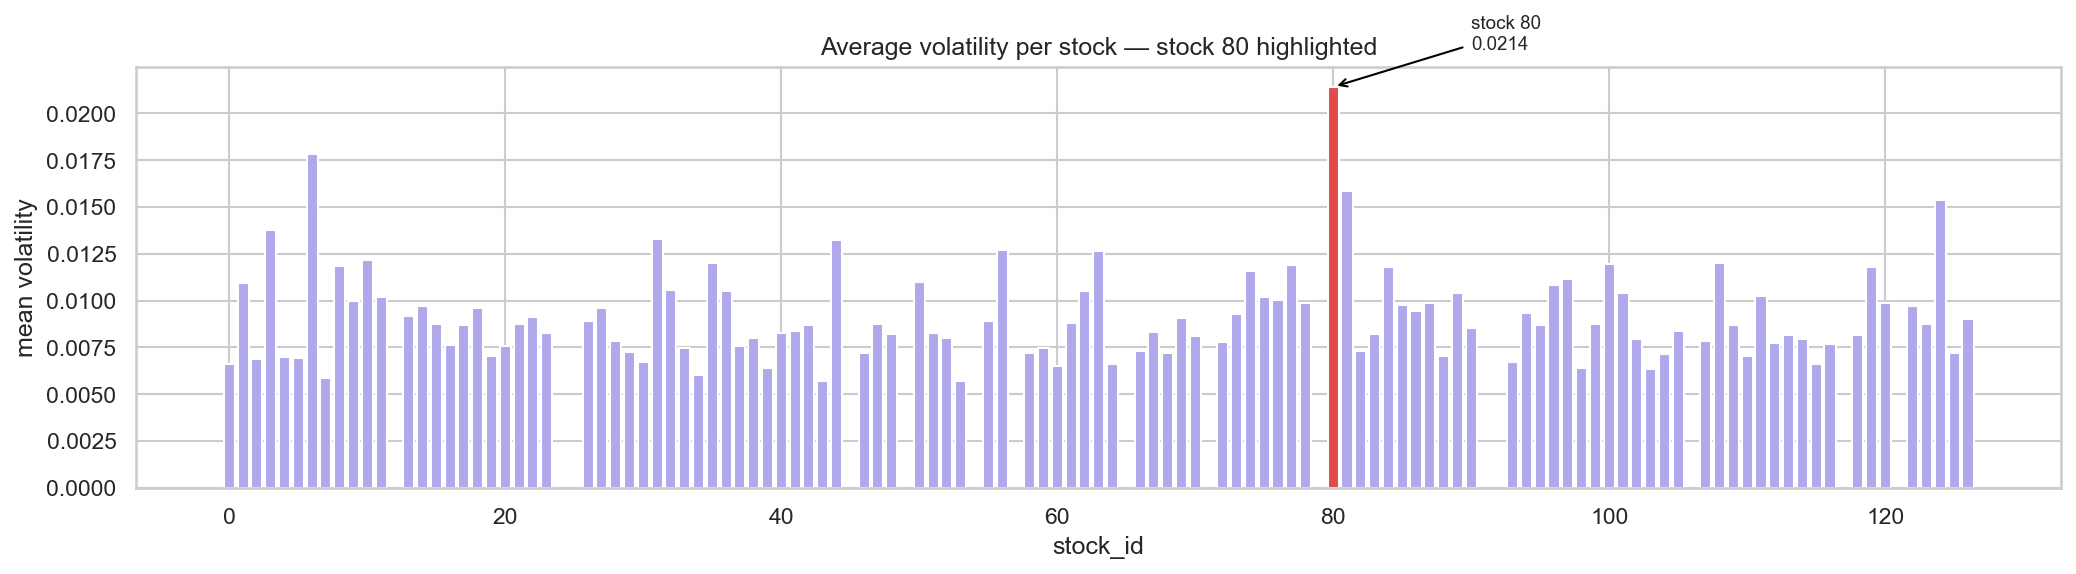

In [24]:
avg_vol = df.groupby('stock_id')['volatility'].mean().reset_index()

# Create color list manually
colors = ['#E24B4A' if sid == 80 else '#AFA9EC' for sid in avg_vol['stock_id']]

plt.figure(figsize=(14, 4))
sns.set_theme(style='whitegrid')

# Use matplotlib bar directly — more reliable for custom colors
plt.bar(avg_vol['stock_id'], avg_vol['volatility'], color=colors, width=0.8)

plt.title('Average volatility per stock — stock 80 highlighted')
plt.xlabel('stock_id')
plt.ylabel('mean volatility')

# Add annotation on stock 80
stock80_val = avg_vol[avg_vol['stock_id'] == 80]['volatility'].values[0]
plt.annotate(f'stock 80\n{stock80_val:.4f}', 
             xy=(80, stock80_val),
             xytext=(90, stock80_val + 0.002),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

plt.tight_layout()
plt.show()

count    111.000000
mean       0.091832
std        0.057241
min        0.009391
25%        0.052802
50%        0.075354
75%        0.116184
max        0.339045
Name: volatility, dtype: float64


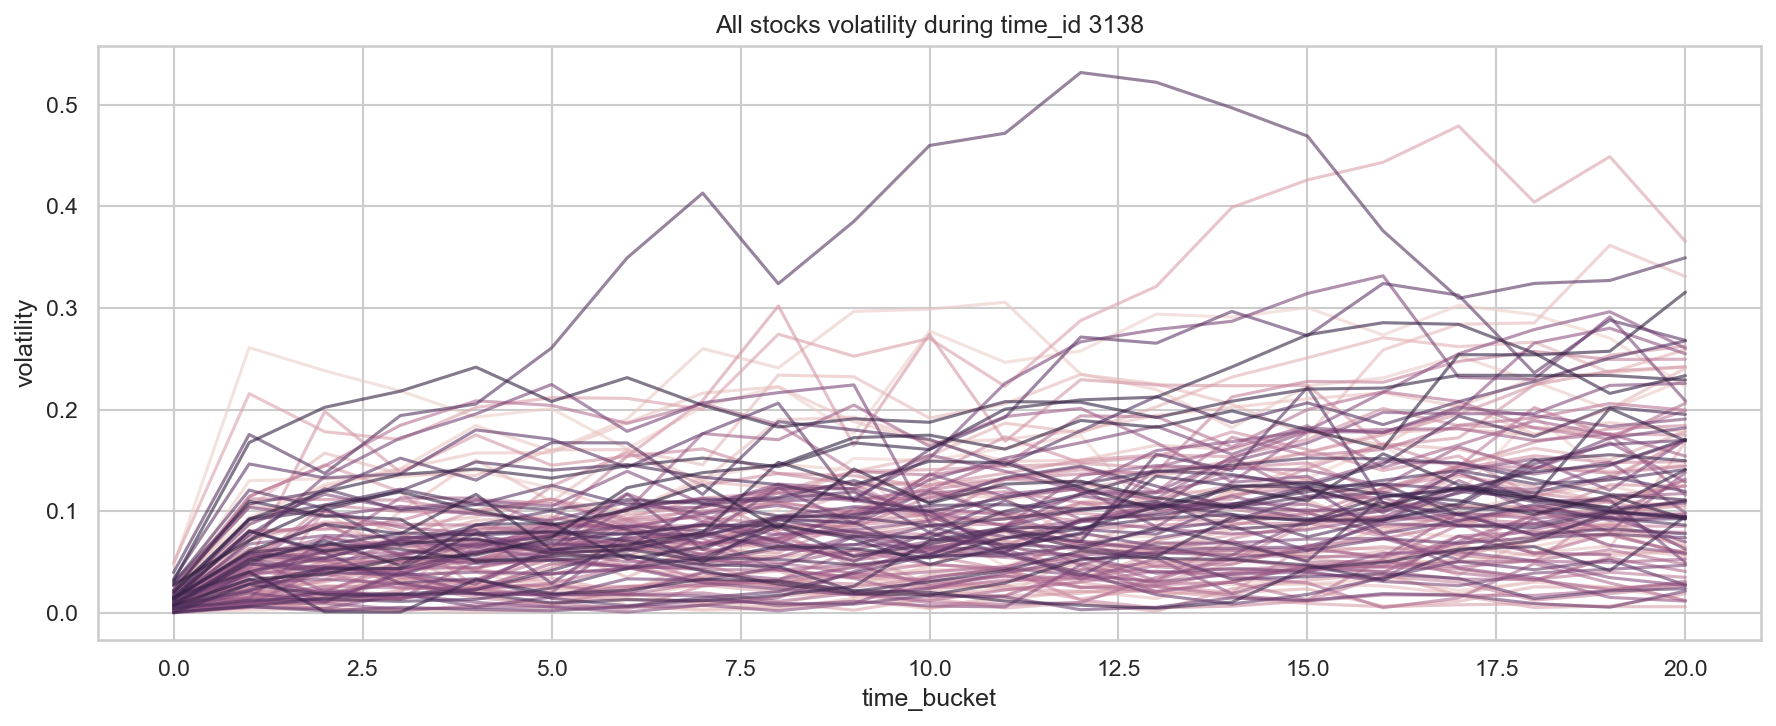

In [26]:
turbulent = df[df['time_id'] == 3138]
print(turbulent.groupby('stock_id')['volatility'].mean().describe())

# Plot volatility across buckets during that time_id
sns.lineplot(data=turbulent, x='time_bucket', y='volatility', 
             hue='stock_id', legend=False, alpha=0.6)
plt.title('All stocks volatility during time_id 3138')
plt.tight_layout()
plt.show()

In [16]:
bucket0 = df[df['time_bucket'] == 0]
zero_starts = bucket0.groupby('time_id')['volatility'].max()
print(f"Time_ids where ALL stocks start at 0: {(zero_starts == 0).sum()}")
print(f"Total time_ids: {df['time_id'].nunique()}")

Time_ids where ALL stocks start at 0: 0
Total time_ids: 3830


In [ ]:
df1 = df[df['time_bucket'] != 0]
print(df1['time_bucket'].unique())  

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]


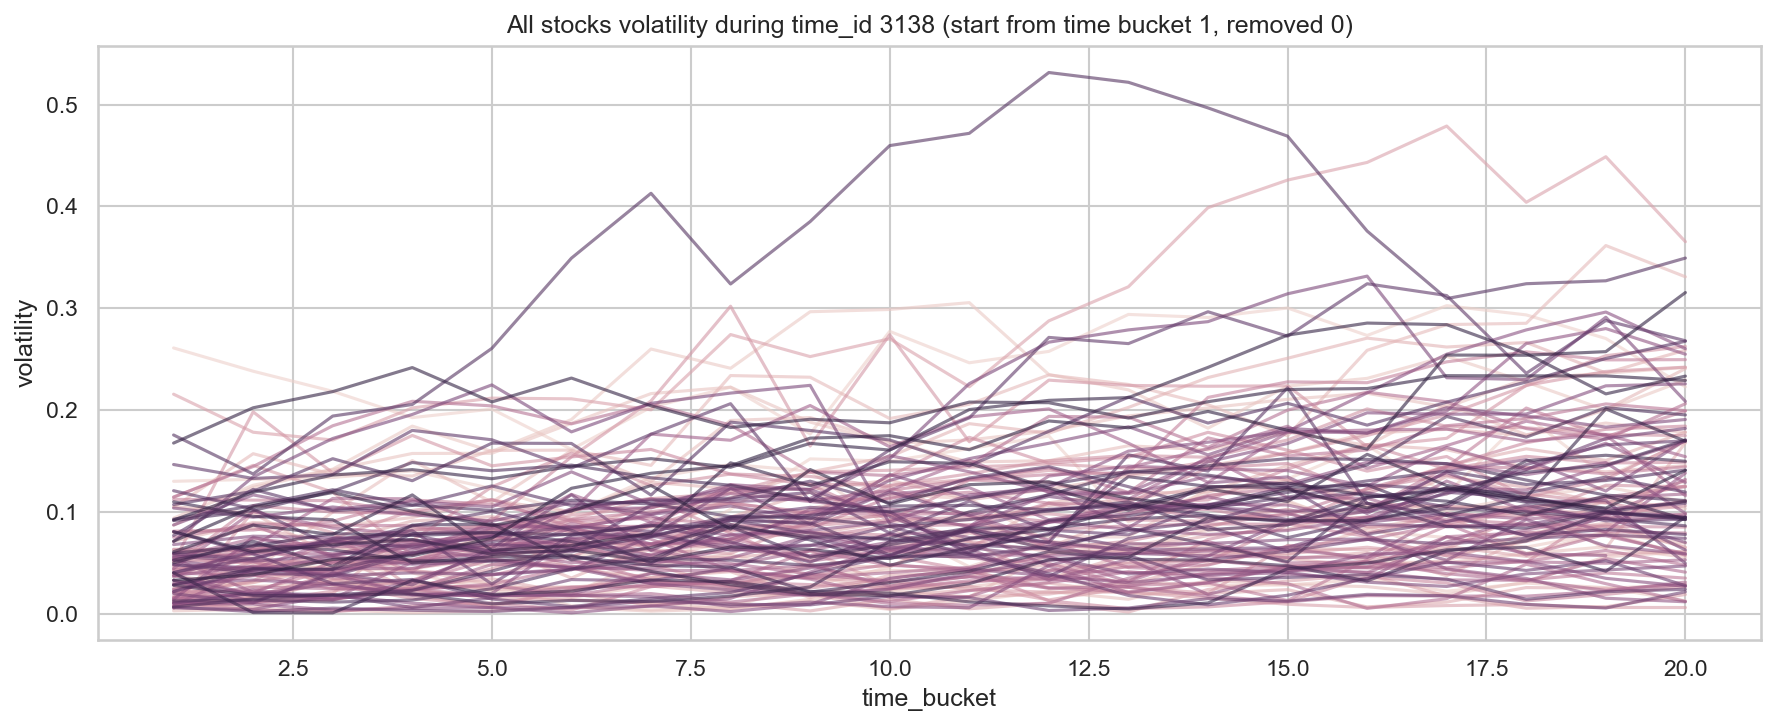

In [28]:
turbulent = df[(df['time_id'] == 3138) & (df['time_bucket'] != 0)]

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 5))
sns.lineplot(data=turbulent, x='time_bucket', y='volatility',
             hue='stock_id', legend=False, alpha=0.6)
plt.title('All stocks volatility during time_id 3138 (start from time bucket 1, removed 0)')
plt.tight_layout()
plt.show()

In [21]:
df.head()

,stock_id,time_id,time_bucket,WAP_mean,BidAskSpread_mean,volatility
0,0,5,0.0,1.001434,0.000878,0.001433
1,0,5,1.0,1.001601,0.000957,0.006366
2,0,5,2.0,1.002978,0.000748,0.009511
3,0,5,3.0,1.003786,0.000876,0.011409
4,0,5,4.0,1.004046,0.000873,0.016157


In [20]:
top_stocks = (df[(df['time_id'] == 3138) & (df['time_bucket'] > 0)]
              .groupby('stock_id')['volatility']
              .mean()
              .sort_values(ascending=False)
              .head(5))
              
print(top_stocks)

stock_id
107    0.354012
27     0.299123
1      0.245131
5      0.214940
102    0.214473
Name: volatility, dtype: float64
